In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
@jit
def lightcurve_to_physical(theta,thS,DS,vEarth, G = 2.959122082855911e-4, KAPPA = 8.1429):
    # G [AU^3 / (Msun * day^2)] , KAPPA [mas / Msun]
    t0 = theta[0]
    tE     = theta[1]
    u0 = theta[2]
    rho    = theta[3]
    q = theta[4]
    s      = theta[5]
    alpha = theta[6]
    piEN   = theta[7]
    piEE   = theta[8]
    vEarth_N, vEarthE = vEarth
    
    G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
    KAPPA = 8.1429 # [mas / Msun]

    piE = jnp.sqrt(piEN**2 + piEE**2)

    thE = thS / rho #mas
    ML = thE / KAPPA / piE #Msun
    murel_geo = thE / tE * 365.25 # mas / year
    murel_N_geo = murel_geo * piEN / piE # mas / year
    murel_E_geo = murel_geo * piEE / piE # mas / year

    pi_rel = thE * piE
    pi_S = 1 / DS
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L #kpc
    
    murel_N_hel = murel_N_geo + thE * piE * vEarth[0]
    murel_E_hel = murel_E_geo + thE * piE * vEarth[1]

    return  jnp.array([ML, DL, DS, murel_N_hel, murel_E_hel])


In [3]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [4]:
import tempfile
import shutil
import os
def read_chain(path, burnin, thin, flat=True):
    tmpdir = tempfile.mkdtemp()
    tmp_path = os.path.join(tmpdir, "chain_copy.h5")
    shutil.copy2(path, tmp_path)

    try:
        sampler = emcee.backends.HDFBackend(tmp_path, read_only=True)
        chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
        blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin)
        lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin)
    finally:
        try:
            os.remove(tmp_path)
            os.rmdir(tmpdir)
        except Exception:
            pass

    return chain, lnprob, blob

In [5]:
def calc_tau(arr):
    taus = []
    for pi in range(arr.shape[2]):
        tau_walkers = []
        for w in range(arr.shape[1]):
            chain = arr[:, w, pi]
            tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
            tau_walkers.append(tau.item())
        mean_tau = np.mean(tau_walkers)
        taus.append(mean_tau)
        print(f"param[{pi}] mean τ_int over {arr.shape[1]} walkers = {mean_tau:.2f}")

    return max(taus)
    

In [6]:
def weighted_percentile(data, weights, percentiles=[16, 50, 84]):
    """Weighted percentile calculation"""
    sorter = np.argsort(data)
    data_sorted = data[sorter]
    weights_sorted = weights[sorter]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(np.array(percentiles)/100, cumsum, data_sorted)

t0_true = 10090 - 5       
u0_true = 0.01
q_true = 0.001
alpha_true = np.pi/2 + 1
tE_true = 30
rho_true = 0.000597948
s_true= 1.14543
piEN_true = 0.0635109
piEE_true = 0.0602449
Ds_true = 8.1
thS_true = 0.0001800539

_truths = [t0_true, tE_true,u0_true, rho_true,
                piEN_true, piEE_true,Ds_true]

truths_lc_04 = [t0_true, tE_true,u0_true, rho_true,q_true,s_true,alpha_true,piEN_true, piEE_true]

truths_kep_04 = parametrics.lightcurve_to_physical_single(_truths,thS_true,vEarth)[2:]

In [7]:
truths_kep_04

Array([0.4224334, 6.674832 , 8.1      , 2.6485143, 2.4214473], dtype=float32)

In [8]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [9]:
label_inds_kep = {"t0": 0, "tE": 1, "u0": 2, "rho": 3, "q": 4, "s": 5, "alpha": 6,
                  "piEN": 7, "piEE": 8, "gamma1": 9, "gamma2": 10, "gamma3": 11,
                  "rs": 12, "as": 13}

label_inds_kep_phys = {"ML": 3, "DL": 4, "DS": 5, "muN": 6, "muE": 7}

In [10]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()

def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T

wt, genuout = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/Ds_prior.dat")


In [11]:
chain_para, blob_para, lnprob_para = read_chain("/moao41_9/nunota/gapmoe/chain_simu09_para.h5",100,10,flat=True)
chain_sta, blob_sta, lnprob_sta = read_chain("/moao41_9/nunota/gapmoe/chain_simu09_sta.h5",100,10,flat=True)

print(np.min(-2*lnprob_para)-np.min(-2*lnprob_sta))

-3.070161805531825


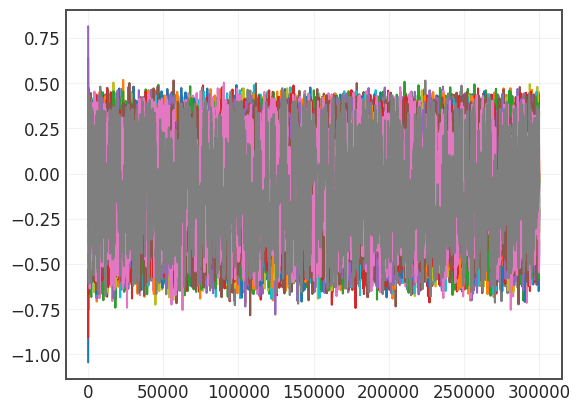

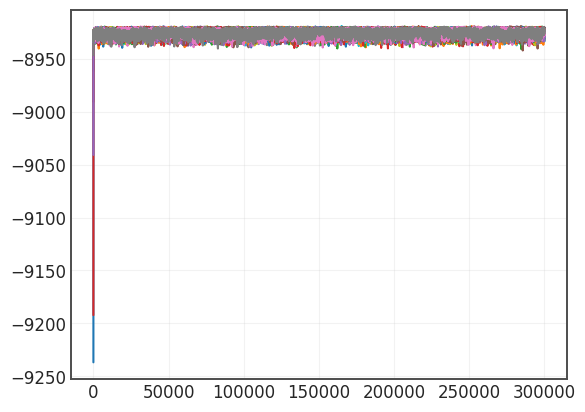

In [12]:
_chain, _blob, _lnprob = read_chain("/moao41_9/nunota/gapmoe/chain_simu09_para.h5",0,1,flat=False)
plt.plot(_chain[:,:,-1])
plt.show()

plt.plot(_lnprob)
plt.show()

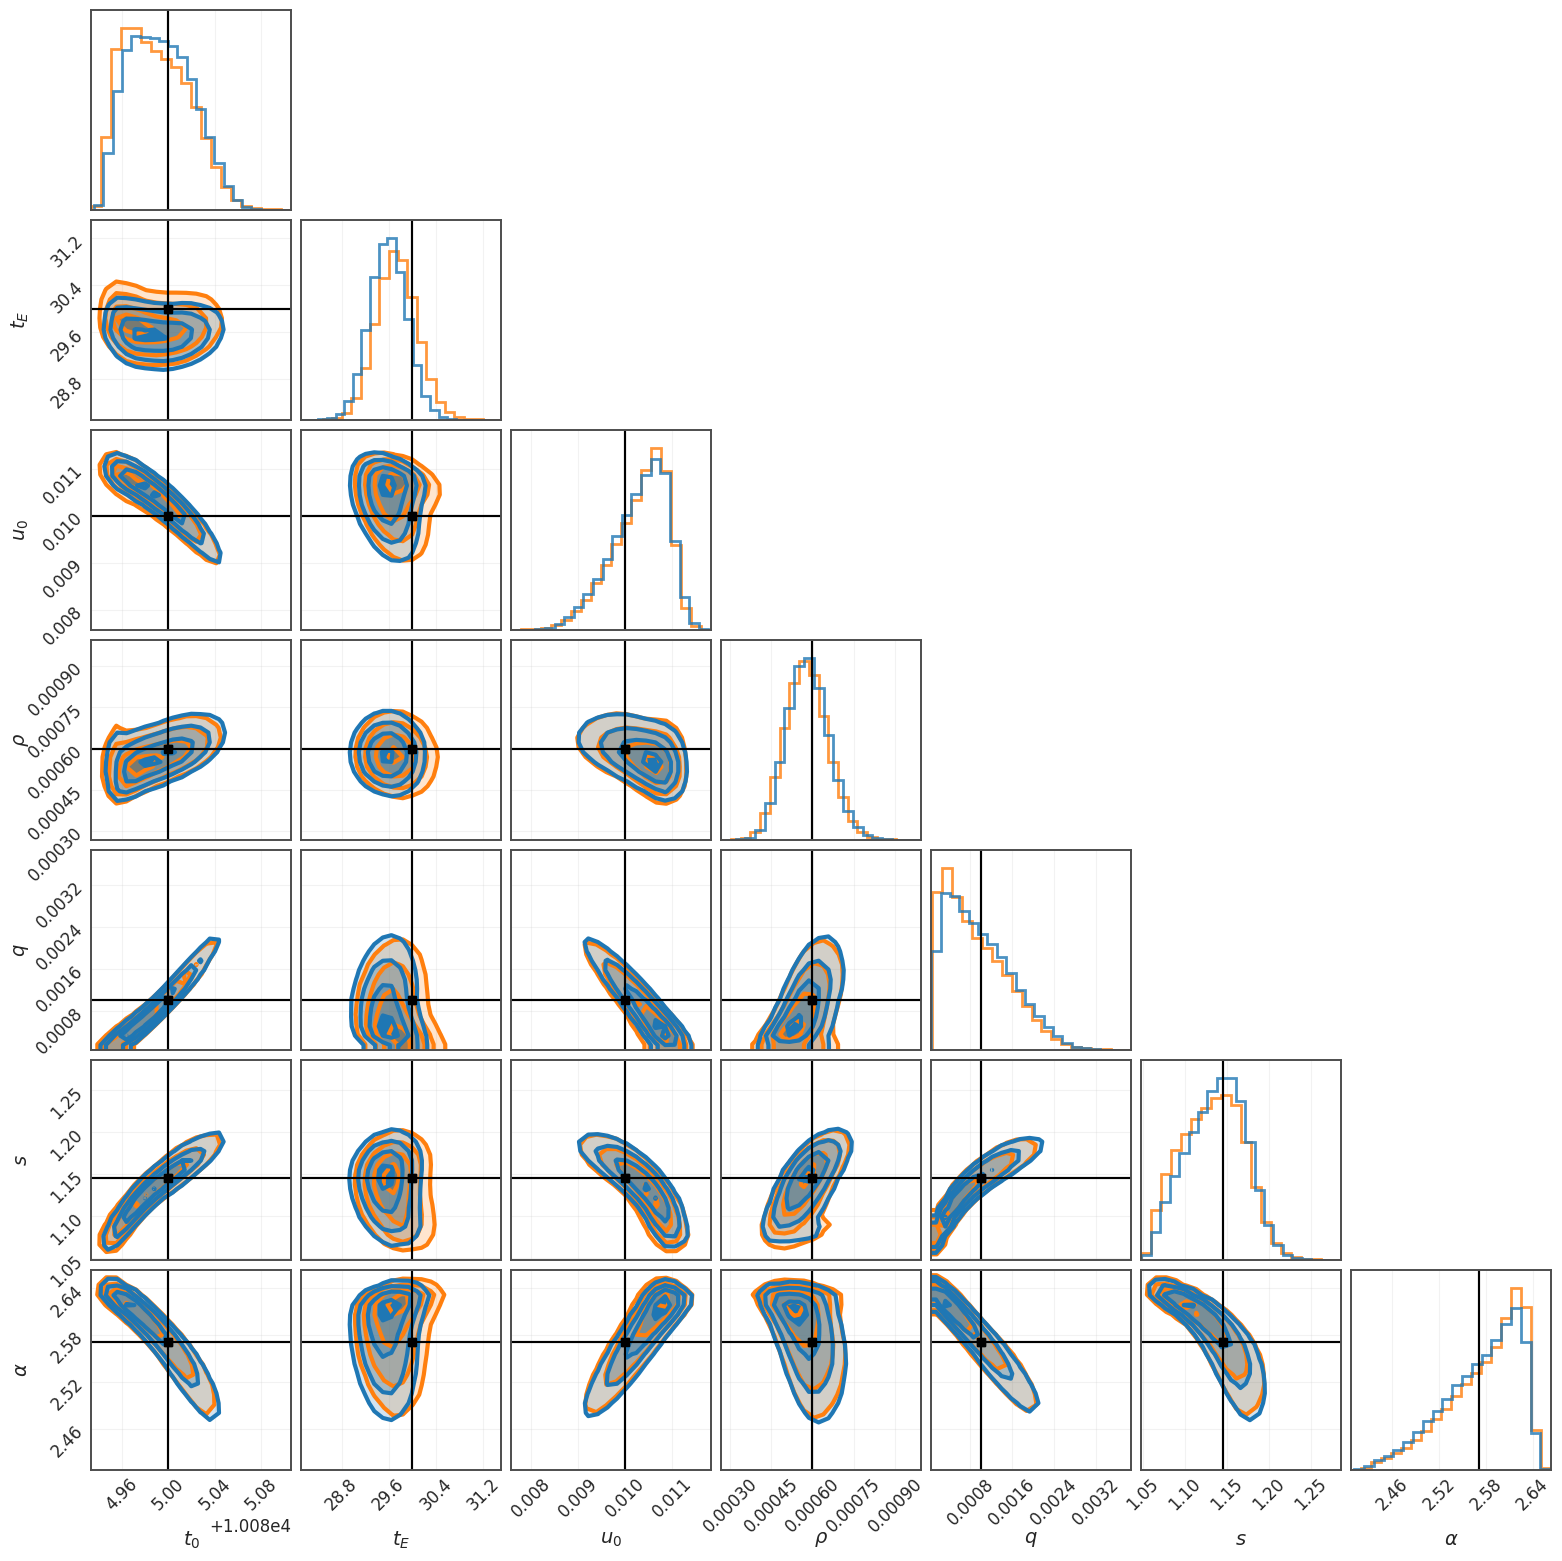

In [13]:
_labels = [
    r"$t_{0}$",
    r"$t_E$",
    r"$u_0$",
    r"$\rho$",
    r"$q$",r"$s$",r"$\alpha$"
]

fig = corner.corner(chain_para[:,:-2],color="C1",labels=_labels,truths=truths_lc_04[:-2],truth_color="k",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)

corner.corner(chain_sta,color="C0",labels=_labels,truths=truths_lc_04[:-2],truth_color="k",fig=fig,
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5,)


handles = [
    Line2D([], [], color="C0", lw=5, label="static"),
    Line2D([], [], color="C1", lw=5, label="parallax"),
]

plt.show()

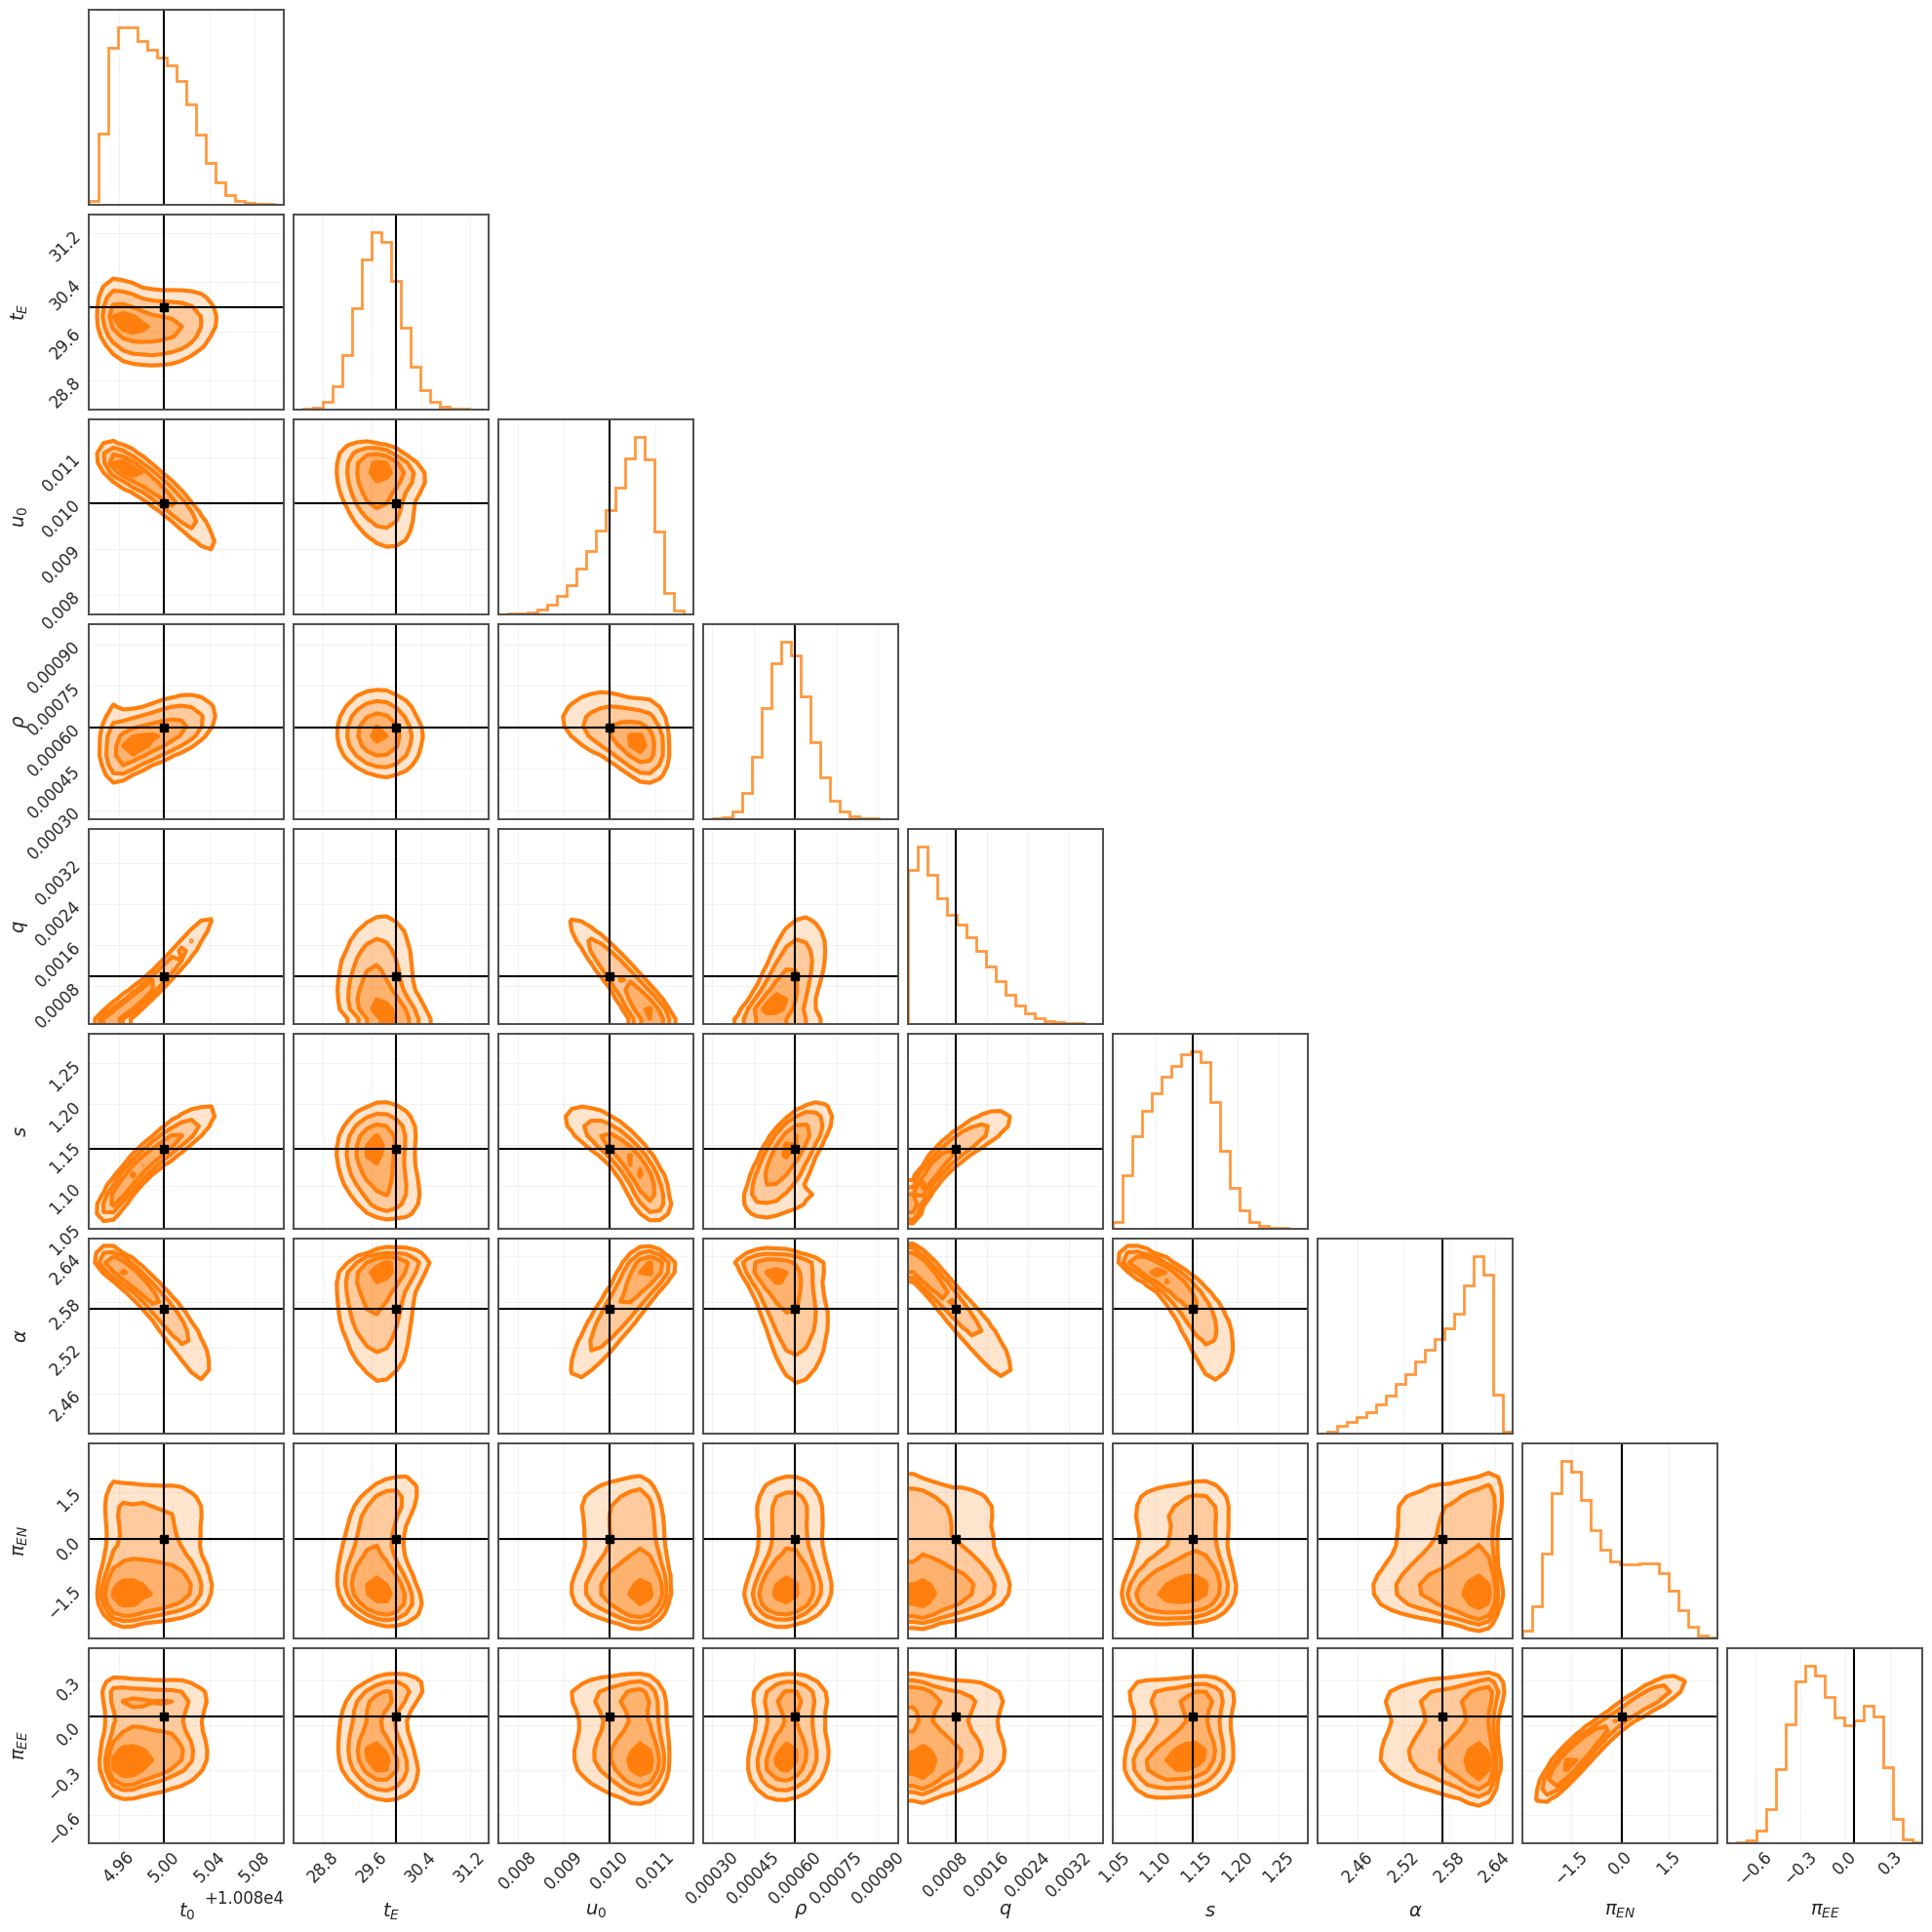

In [14]:
_labels = [
    r"$t_{0}$",
    r"$t_E$",
    r"$u_0$",
    r"$\rho$",
    r"$q$",r"$s$",r"$\alpha$","$\pi_{EN}$","$\pi_{EE}$"
]

fig = corner.corner(chain_para,color="C1",labels=_labels,truths=truths_lc_04,truth_color="k",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8, "histtype": "step","zorder":2},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 2, "linewidths": 3},
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=.5)

handles = [
    Line2D([], [], color="C0", lw=5, label="static"),
    Line2D([], [], color="C1", lw=5, label="parallax"),
]

plt.show()

In [15]:
Ds = genuout[:chain_para.shape[0], 2]  # shape: (N,)

_vmap = jax.vmap(
    lambda theta, thS, D_S : lightcurve_to_physical(theta, thS, D_S, vEarth),
    in_axes=(0, 0, 0)
)

result = np.array(_vmap(chain_para, blob_para, Ds))

In [16]:
bounds = {
#     "tE":    (30, 90),
#     "rho":   (0.00055, 0.00065),
    "tE":    (28, 32),
    "rho":   (3e-4, 8e-4),
    "piEN":  (-3, 3),
    "piEE":  (-3, 3),
}

rng = np.random.default_rng(seed=45)
samples = np.stack([
    rng.uniform(low, high,chain_para.shape[0] )
    for (low, high) in bounds.values()], axis=-1)

uni_chain = chain_para.copy()
uni_chain[:,1] = samples[:,0]
uni_chain[:,3] = samples[:,1]
uni_chain[:,7] = samples[:,2]
uni_chain[:,8] = samples[:,3]

_vmap_2 = jax.vmap(
    lambda theta, D_S: lightcurve_to_physical(theta, thS_true, D_S, vEarth),
    in_axes=(0, 0)
)

result_prior = np.array(_vmap(uni_chain, blob_para, Ds))

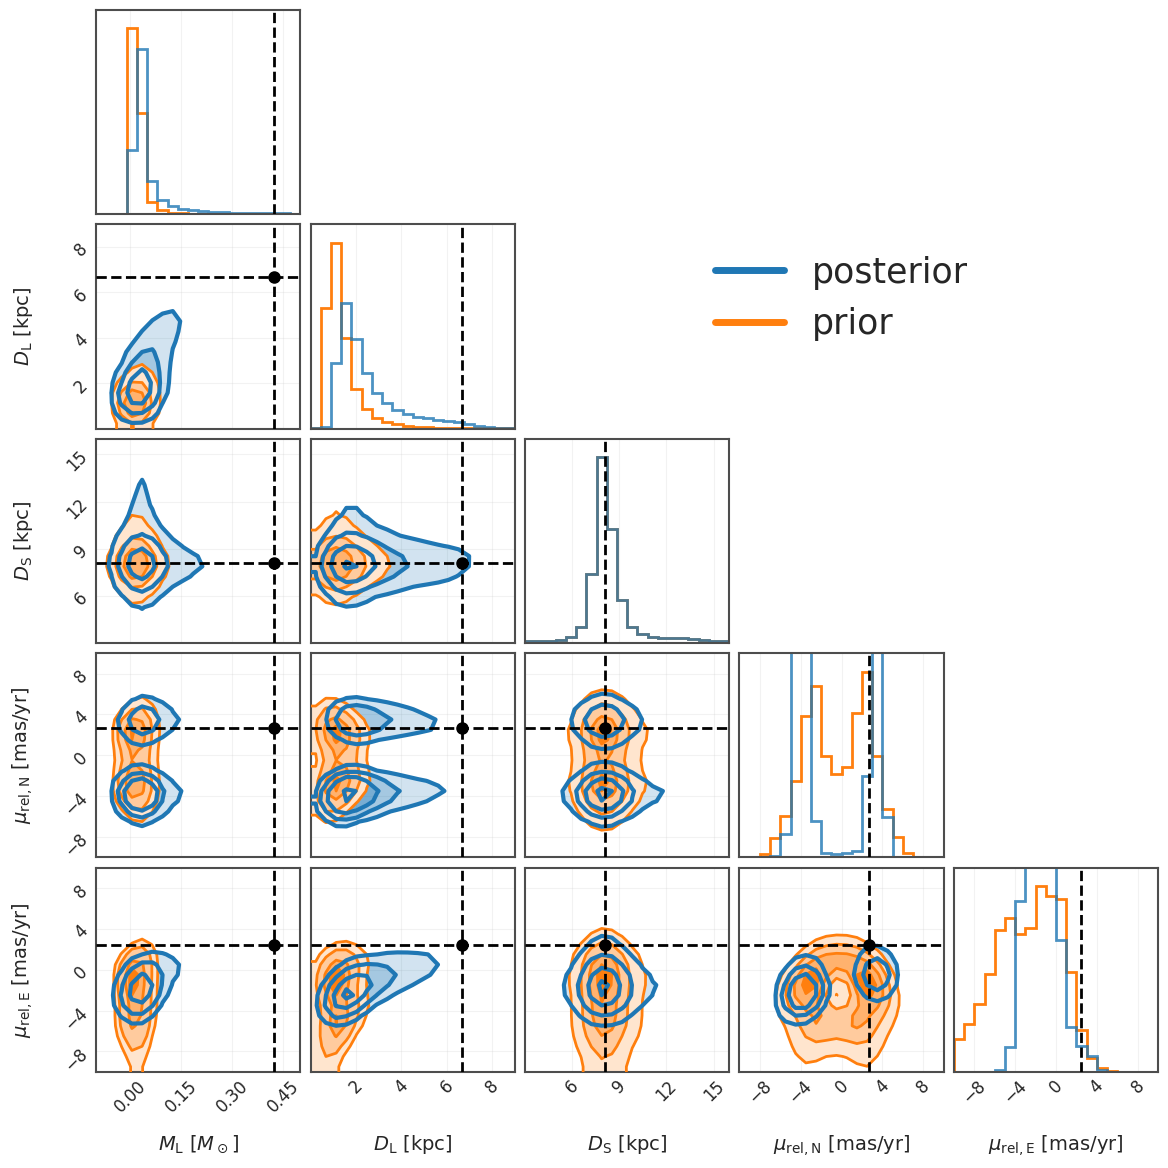

In [17]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0.1, 0.5),   # M_L
    (0, 9),       # D_L
    (3, 16),       # D_S
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------
fig = corner.corner(
    result,               # shape: (Nsamples, 5) を想定
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior,        # shape: (Nsamples_prior, 5) を想定
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

ndim = result.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------
truths = truths_kep_04[:5]

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# ylims = [
#     (0, 13),    # M_L
#     (0, 2),  # D_L
#     (0, 0.6),  # D_S
#     (0, 0.5),  # mu_rel_N
#     (0, 0.55),    # mu_rel_E
# ]

# for i in range(ndim):
#     ax = axes[i, i]
#     ax.set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -2].legend(
    handles=handles,
    fontsize=25,
    loc="upper center",
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


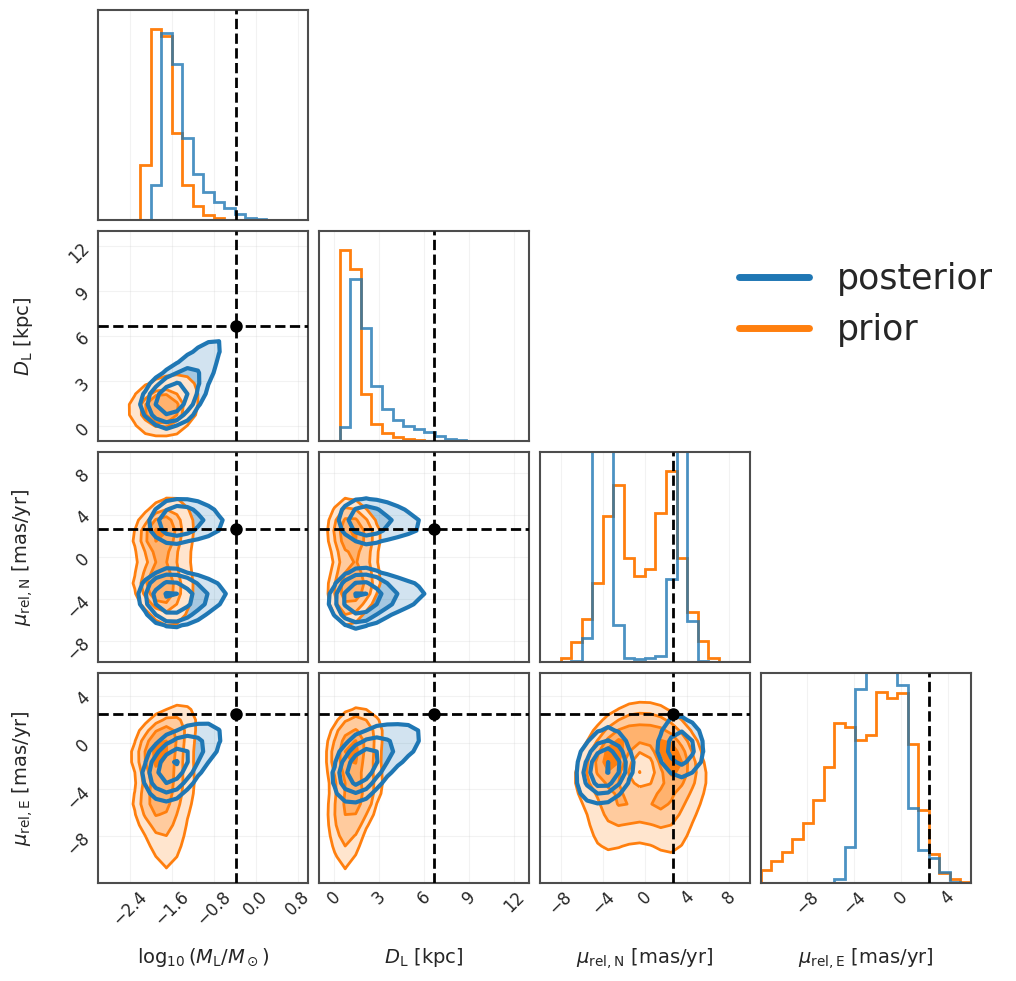

In [18]:
labels_phys = [
    r"$\log_{10} (M_{\rm L} / {M_\odot})$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-3, 1),
    (-1, 13),
    (-10, 10),
    (-12,6),
]

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()
result_plot = result_plot[np.where((result_plot[:,0]<2)&(result_plot[:,1]<10))]
result_plot[:,0] = np.log10(result_plot[:,0])
result_prior_plot[:,0] = np.log10(result_prior_plot[:,0])
truths[0] = np.log10(truths[0])

fig = corner.corner(
    result_plot,
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges,
    color="C1",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    contour_kwargs={
        "zorder": 3,
        "linewidths": 2,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(truths[j], truths[i], "o", color="k", ms=8, zorder=10)

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

# ylims = [
#     (0, 13),
#     (0, 2),
#     (0, 0.5),
#     (0, 0.55),
# ]

# for i in range(ndim):
#     axes[i, i].set_ylim(ylims[i])

handles = [
    Line2D([], [], color="C0", lw=5, label="posterior"),
    Line2D([], [], color="C1", lw=5, label="prior"),
]

axes[1, -1].legend(
    handles=handles,
    fontsize=25,
    loc="upper center",
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


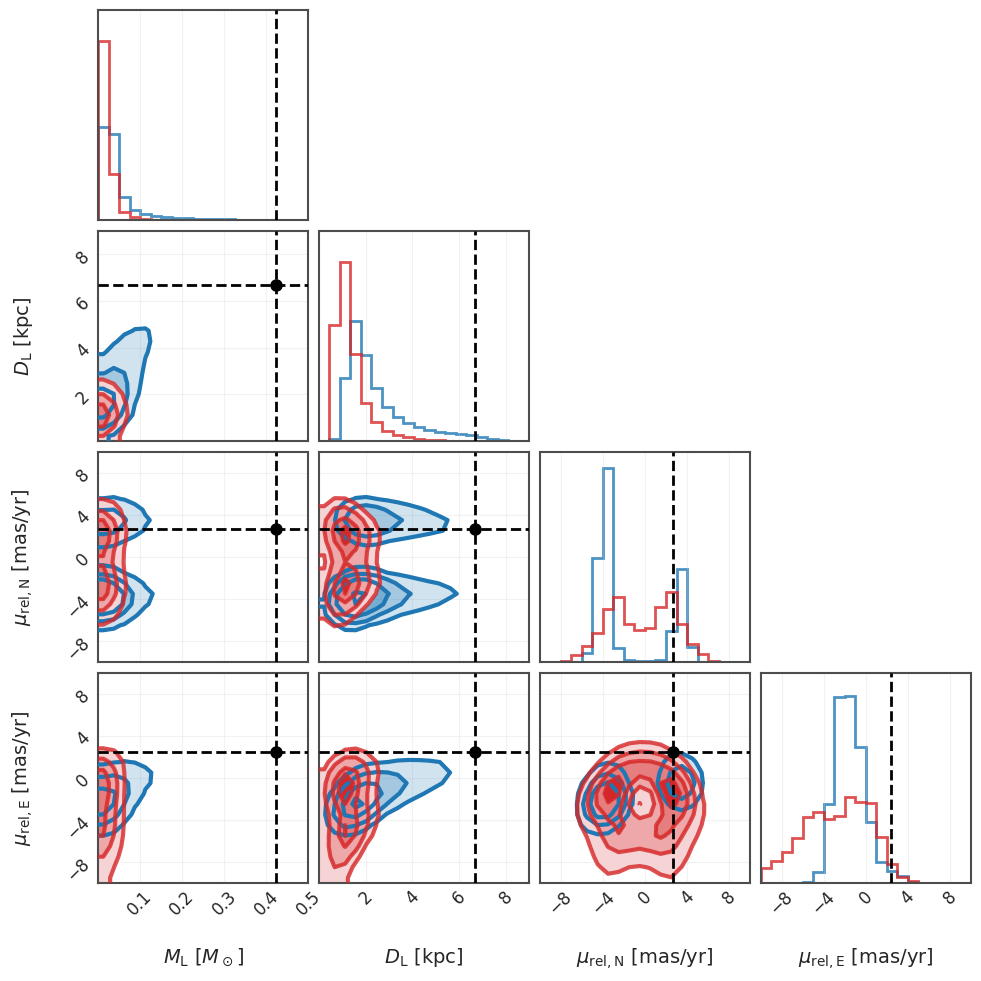

In [19]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0., 0.5),   # M_L
    (0, 9),       # D_L
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,               # shape: (Nsamples, 5) を想定
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 0,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior_plot,        # shape: (Nsamples_prior, 5) を想定
    fig=fig,
    range=ranges,
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 8,
        "linewidths": 3,"alpha":0.8
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 35),    # M_L
    (0, 1),  # D_L
    (0, 0.45),  # mu_rel_N
    (0, 0.3),    # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


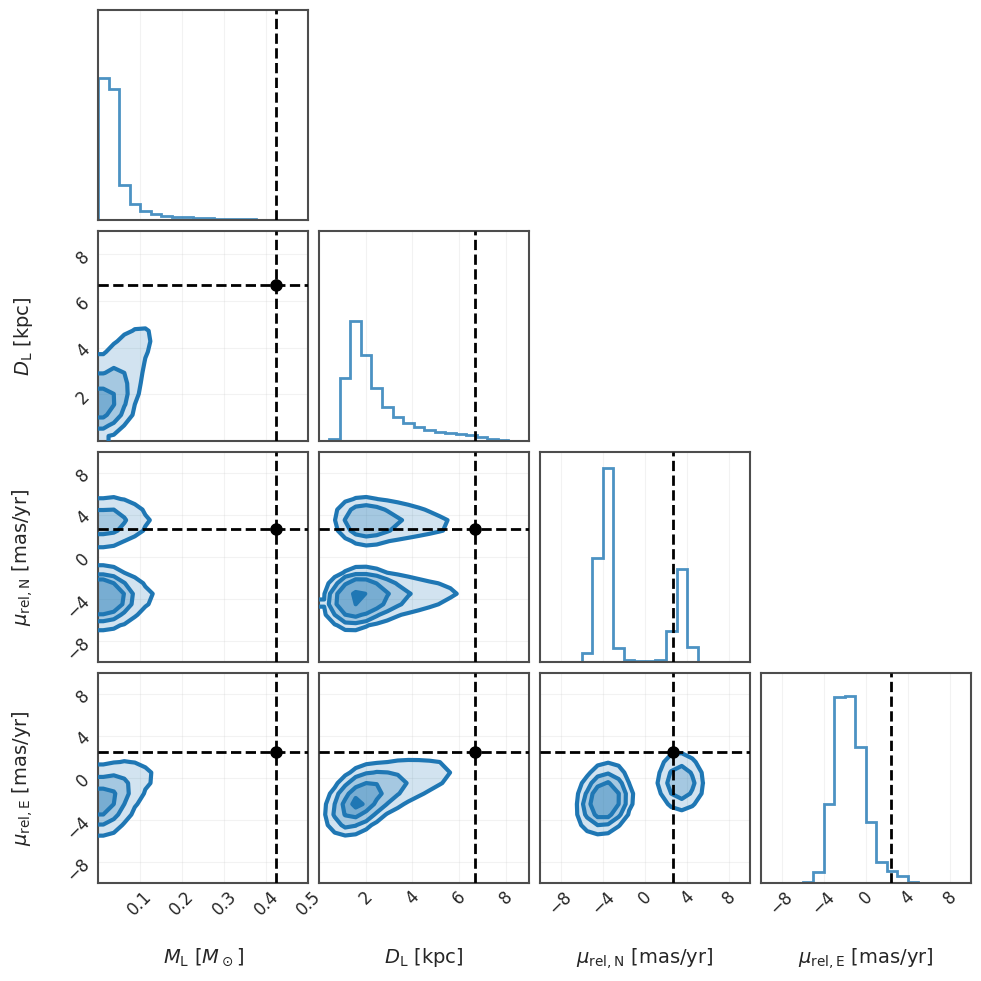

In [20]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0., 0.5),   # M_L
    (0, 9),       # D_L
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------

idx = [0, 1, 3, 4]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,               # shape: (Nsamples, 5) を想定
    labels=labels_phys,
    range=ranges,
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)



ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 23),    # M_L
    (0, 1),  # D_L
    (0, 0.45),  # mu_rel_N
    (0, 0.3),    # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


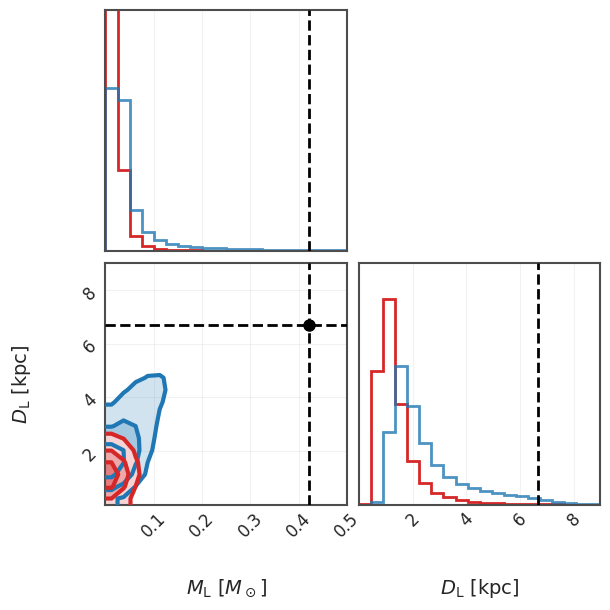

In [21]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 各パラメータの表示レンジ（さっきの例をそのまま採用）
ranges = [
    (-0., 0.5),   # M_L
    (0, 9),       # D_L
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------

idx = [0, 1]
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths = np.array(truths_kep_04)[idx].copy()

fig = corner.corner(
    result_plot,               # shape: (Nsamples, 5) を想定
    labels=labels_phys[:2],
    range=ranges[:2],
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)

corner.corner(
    result_prior_plot,        # shape: (Nsamples_prior, 5) を想定
    fig=fig,
    range=ranges[:2],
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 8,
        "linewidths": 3,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=1
)


ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 23),    # M_L
    (0, 1),  # D_L
    (0, 0.45),  # mu_rel_N
    (0, 0.3),    # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


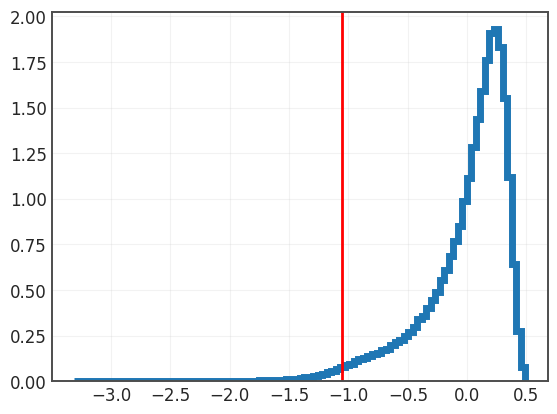

In [22]:
piE = np.sqrt(chain_para[:,-1]**2+chain_para[:,-2]**2)
plt.hist(np.log10(piE),histtype="step",density=True,linewidth=5,bins=100)

piE_true = np.sqrt(piEN_true**2 + piEE_true**2)
plt.axvline(np.log10(piE_true),lw=2,c="red")

plt.minorticks_on()
plt.show()

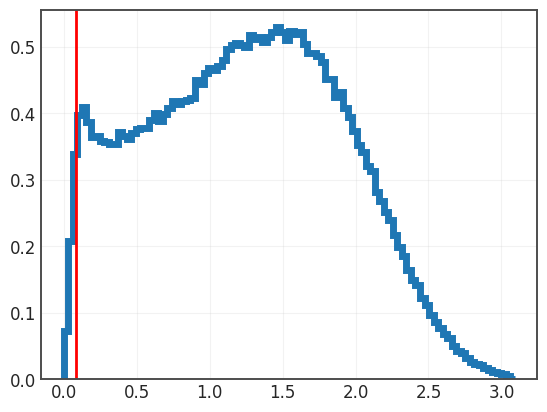

In [23]:
plt.hist((piE),histtype="step",density=True,linewidth=5,bins=100)

piE_true = np.sqrt(piEN_true**2 + piEE_true**2)
plt.axvline((piE_true),lw=2,c="red")

plt.minorticks_on()
plt.show()

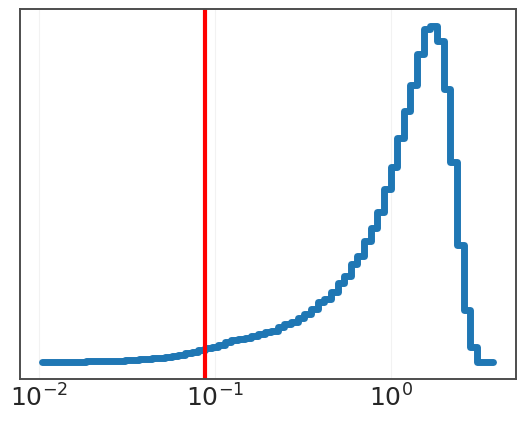

In [24]:

bins = np.logspace(-2, 0.6, 70)

h, edges = np.histogram(piE, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])  

h_log10 = h * centers * np.log(10)

plt.step(centers, h_log10, where="mid", linewidth=5)

piE_true = np.sqrt(piEN_true**2 + piEE_true**2)
plt.axvline(piE_true, lw=3, c="red")

plt.xscale("log")
plt.yscale("linear")
plt.yticks([])
plt.minorticks_on()
ax = plt.gca()
ax.tick_params(axis="x", labelsize=18)
plt.show()


In [25]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_prior = "../test_gal_result/genout_prior.dat"
data_gal_prior = np.genfromtxt(path_prior, names=column_names)

data_gal_muN = data_gal_prior["mu_rel"] * np.cos(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
data_gal_muE = data_gal_prior["mu_rel"] * np.sin(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
mu_tot_flat = np.sqrt(data_gal_muN**2 + data_gal_muE**2)
mask_flat = mu_tot_flat < 20

gal_prior = np.vstack([
    (data_gal_prior["M_L"][mask_flat]),
    (data_gal_prior["D_L"][mask_flat] * 1e-3),
]).T

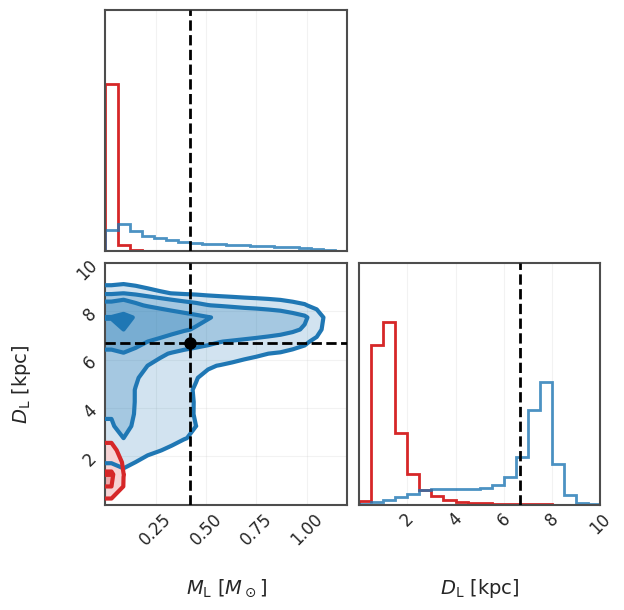

In [26]:
# 物理パラメータのラベル（順番は result / truths_kep_04 に合わせて）
labels_phys = [
    r"$M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

ranges = [
    (-0., 1.2),   # M_L
    (0, 10),       # D_L
    (-10, 10),       # mu_rel_N
    (-10, 10),       # mu_rel_E
]

# ------------------------
# posterior（result）の corner
# ------------------------

idx = [0, 1]

result_prior_plot = result_prior[:, idx].copy()
truths = np.array([truths_kep_04[0],truths_kep_04[1]])

fig = corner.corner(
    gal_prior,               # shape: (Nsamples, 5) を想定
    labels=labels_phys[:2],
    range=ranges[:2],
    color="C0",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 0.8,
        "histtype": "step",
        "zorder": 2,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 5,
        "linewidths": 3,
    },
    fill_contours=True,
    no_fill_contours=True,   # 塗りつぶし輪郭＋線だけ輪郭
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=0.5
)

corner.corner(
    result_prior_plot, 
    fig=fig,
    range=ranges[:2],
    color="C3",
    hist_kwargs={
        "density": True,
        "linewidth": 2,
        "alpha": 1.0,
        "histtype": "step",
        "zorder": 1,
    },
    label_kwargs={"fontsize": 14},
    contour_kwargs={
        "zorder": 8,
        "linewidths": 3,
    },
    fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,smooth=0.5
)


ndim = result_plot.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            labelsize=12,
        )
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン（truths_kep_04[:5]）を描く
# ------------------------

# オフダイアゴナル：交点＋縦横の破線
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths[i], color="k", linestyle="--", lw=2, zorder=9)
        ax.axvline(truths[j], color="k", linestyle="--", lw=2, zorder=9)
        ax.plot(
            truths[j],
            truths[i],
            "o",
            color="k",
            markersize=8,
            zorder=10,
        )

# 対角成分：縦線だけ
for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(truths[i], color="k", linestyle="--", lw=2, zorder=9)

ylims = [
    (0, 23),    # M_L
    (0, 1),  # D_L
    (0, 0.45),  # mu_rel_N
    (0, 0.3),    # mu_rel_E
]

for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.98,
    wspace=0.05,
    hspace=0.05,
)

plt.show()


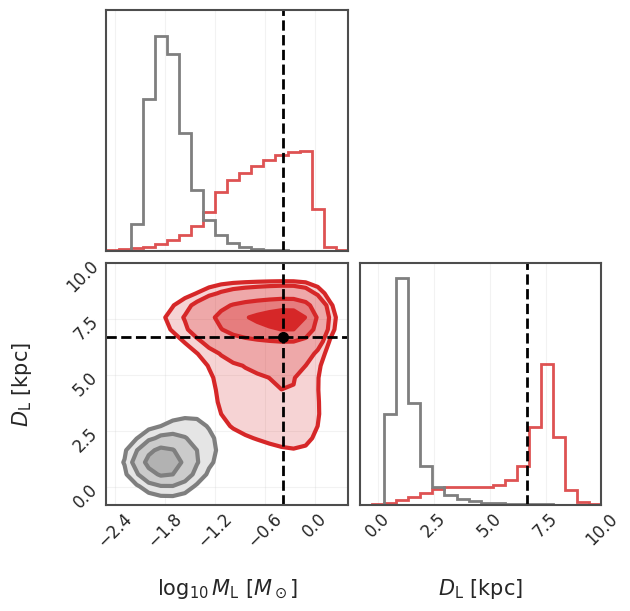

In [27]:
# ------------------------
# 使う次元
# ------------------------
idx = [0, 1]

# データコピー
gal_plot = gal_prior[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths_plot = np.array([truths_kep_04[0], truths_kep_04[1]])

# ===== M_L だけ log10 =====
gal_plot[:, 0] = np.log10(gal_plot[:, 0])
result_prior_plot[:, 0] = np.log10(result_prior[:, 0])
truths_plot[0] = np.log10(truths_plot[0])

# ラベル
labels_plot = [
    r"$\log_{10} M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
]

# 表示範囲
ranges_plot = [
    (-2.5, 0.4),   # log10(M_L)
    (-0.8, 10),       # D_L（線形）
]

# ------------------------
# corner plot
# ------------------------
fig = corner.corner(
    gal_plot,
    labels=labels_plot,
    range=ranges_plot,
    color="C3",
    hist_kwargs=dict(density=True, linewidth=2, alpha=0.8, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    no_fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges_plot,
    color="C7",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# corner.corner(
#     result_plot,
#     fig=fig,
#     range=ranges_plot,
#     color="C7",
#     hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
#     contour_kwargs=dict(linewidths=3),
#     fill_contours=True,
#     plot_density=False,
#     plot_datapoints=False,
#     smooth=0.5,
# )

# ------------------------
# 軸整形
# ------------------------
ndim = len(idx)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン
# ------------------------
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths_plot[i], color="k", linestyle="--", lw=2)
        ax.axvline(truths_plot[j], color="k", linestyle="--", lw=2)
        ax.plot(truths_plot[j], truths_plot[i], "o", color="k", ms=7)

for i in range(ndim):
    axes[i, i].axvline(truths_plot[i], color="k", linestyle="--", lw=2)

# 対角ヒストの高さ調整（必要なら）
ylims = [
    (0, 2),   # log10(M_L)
    (0, .9),   # D_L
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08, right=0.98, bottom=0.08, top=0.98,
    wspace=0.05, hspace=0.05
)

plt.show()


In [35]:
gap_result = np.load("../gmp2.npy")

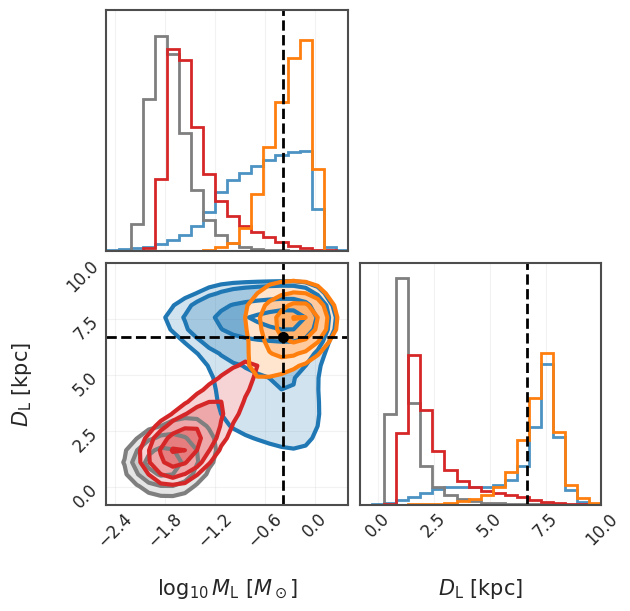

In [39]:
# ------------------------
# 使う次元
# ------------------------
idx = [0, 1]

# データコピー
gal_plot = gal_prior[:, idx].copy()
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths_plot = np.array([truths_kep_04[0], truths_kep_04[1]])

# ===== M_L だけ log10 =====
gal_plot[:, 0] = np.log10(gal_plot[:, 0])
result_plot[:, 0] = np.log10(result_plot[:, 0])
result_prior_plot[:, 0] = np.log10(result_prior_plot[:, 0])
truths_plot[0] = np.log10(truths_plot[0])

# ラベル
labels_plot = [
    r"$\log_{10} M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
]

# 表示範囲
ranges_plot = [
    (-2.5, 0.4),   # log10(M_L)
    (-0.8, 10),       # D_L（線形）
]

# ------------------------
# corner plot
# ------------------------
fig = corner.corner(
    gal_plot,
    labels=labels_plot,
    range=ranges_plot,
    color="C0",
    hist_kwargs=dict(density=True, linewidth=2, alpha=0.8, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    no_fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges_plot,
    color="C7",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_plot,
    fig=fig,
    range=ranges_plot,
    color="C3",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    gap_result,
    fig=fig,
    range=ranges_plot,
    color="C1",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(linewidths=3,alpha=1),
    fill_contours=True,
    plot_density=True,
    plot_datapoints=False,
    smooth=1,
)

# ------------------------
# 軸整形
# ------------------------
ndim = len(idx)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# ------------------------
# 真値ライン
# ------------------------
for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axhline(truths_plot[i], color="k", linestyle="--", lw=2)
        ax.axvline(truths_plot[j], color="k", linestyle="--", lw=2)
        ax.plot(truths_plot[j], truths_plot[i], "o", color="k", ms=7)

for i in range(ndim):
    axes[i, i].axvline(truths_plot[i], color="k", linestyle="--", lw=2)

# 対角ヒストの高さ調整（必要なら）
ylims = [
    (0, 2),   # log10(M_L)
    (0, .9),   # D_L
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08, right=0.98, bottom=0.08, top=0.98,
    wspace=0.05, hspace=0.05
)

plt.show()


In [33]:
np.save("../tmp",result_plot)

In [29]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_prior = "../test_gal_result/genout_prior.dat"
data_gal_prior = np.genfromtxt(path_prior, names=column_names)

data_gal_muN = data_gal_prior["mu_rel"] * np.cos(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
data_gal_muE = data_gal_prior["mu_rel"] * np.sin(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
mu_tot_flat = np.sqrt(data_gal_muN**2 + data_gal_muE**2)
mask_flat = mu_tot_flat < 20

gal_prior = np.vstack([
    (data_gal_prior["M_L"][mask_flat]),
    (data_gal_prior["D_L"][mask_flat] * 1e-3),
        (data_gal_prior["D_S"][mask_flat] * 1e-3),data_gal_muN[mask_flat],data_gal_muE[mask_flat]
]).T

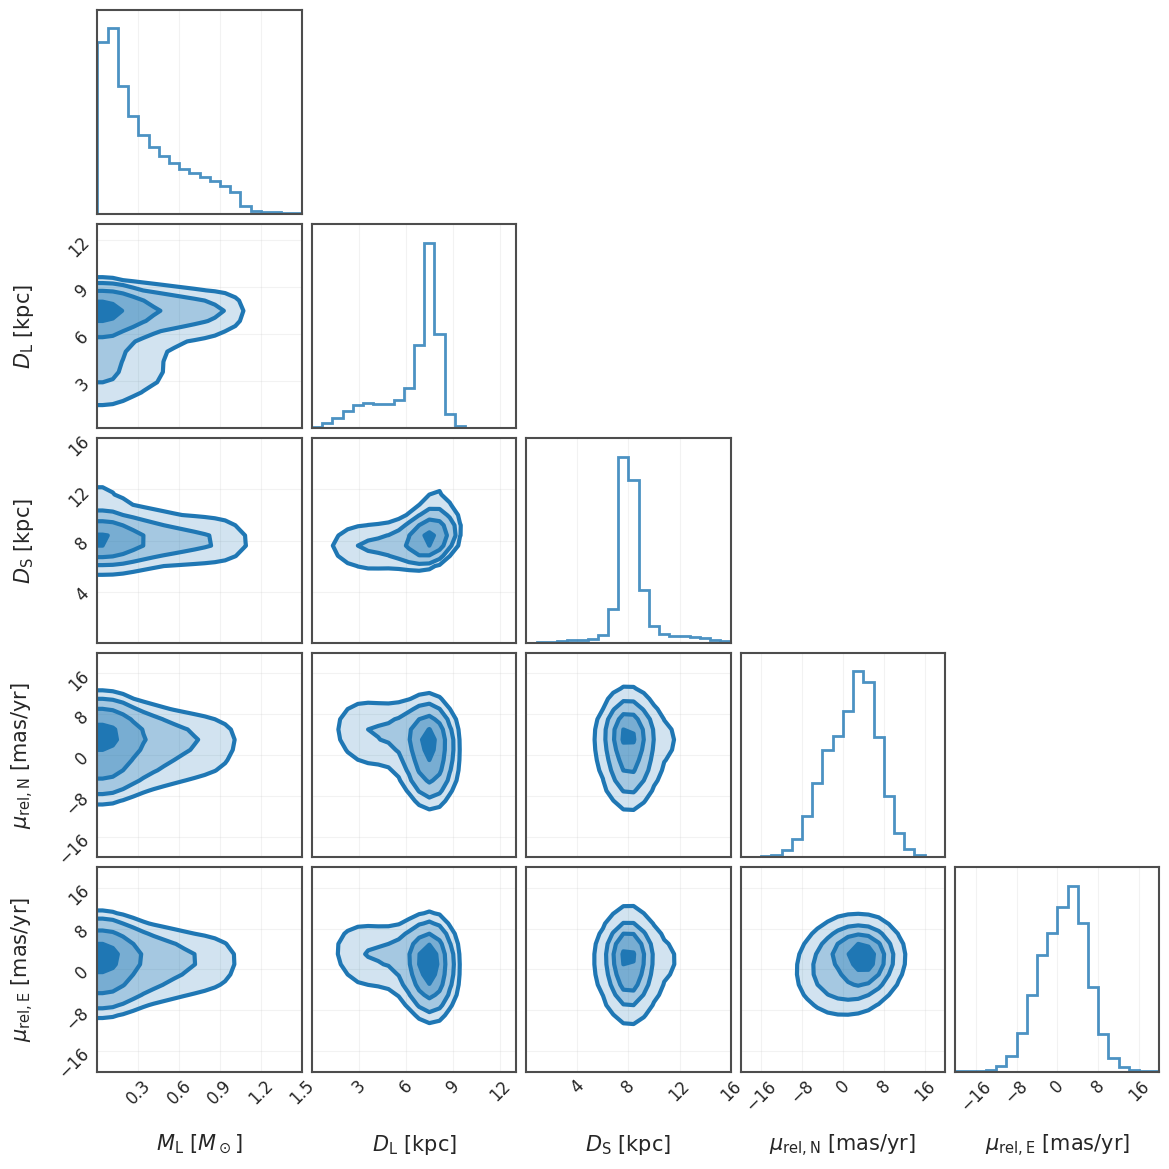

In [30]:

# ------------------------
# 使う次元
# ------------------------
idx = [0, 1,2,3,4]

# データコピー
gal_plot = gal_prior[:, idx].copy()
result_plot = result[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths_plot = np.array(result_prior)[idx]

# ===== M_L だけ log10 =====
labels_plot = [
    r"$ M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$",
]

# 表示範囲
ranges_plot = [
    (0, 1.5),   # log10(M_L)
    (0, 13),       # D_L（線形）
    (0, 16),       # D_S
    (-20, 20),       # mu_rel_N
    (-20, 20),       # mu_rel_E
]

# ------------------------
# corner plot
# ------------------------
fig = corner.corner(
    gal_plot,
    labels=labels_plot,
    range=ranges_plot,
    color="C0",
    hist_kwargs=dict(density=True, linewidth=2, alpha=0.8, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    no_fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# ------------------------
# 軸整形
# ------------------------
ndim = len(idx)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

fig.subplots_adjust(
    left=0.08, right=0.98, bottom=0.08, top=0.98,
    wspace=0.05, hspace=0.05
)

plt.show()


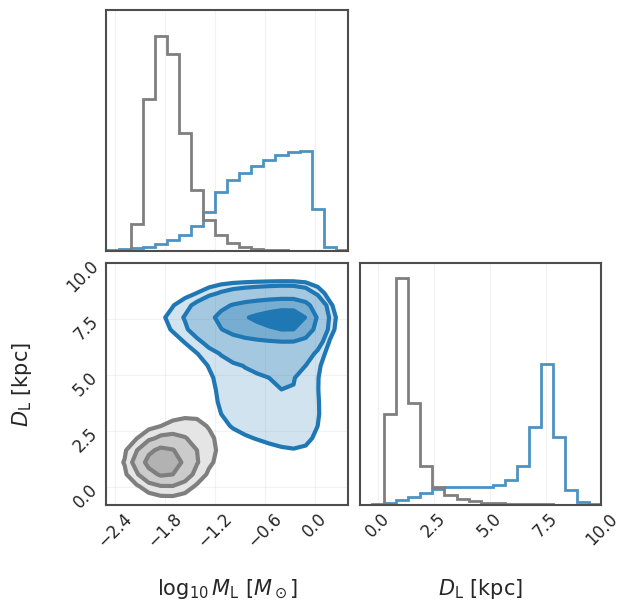

In [31]:
# ------------------------
# 使う次元
# ------------------------
idx = [0, 1]

# データコピー
gal_plot = gal_prior[:, idx].copy()
result_prior_plot = result_prior[:, idx].copy()
truths_plot = np.array([truths_kep_04[0], truths_kep_04[1]])

# ===== M_L だけ log10 =====
gal_plot[:, 0] = np.log10(gal_plot[:, 0])
result_prior_plot[:, 0] = np.log10(result_prior[:, 0])
truths_plot[0] = np.log10(truths_plot[0])

# ラベル
labels_plot = [
    r"$\log_{10} M_{\rm L}\ [{M_\odot}]$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
]

# 表示範囲
ranges_plot = [
    (-2.5, 0.4),   # log10(M_L)
    (-0.8, 10),       # D_L（線形）
]

# ------------------------
# corner plot
# ------------------------
fig = corner.corner(
    gal_plot,
    labels=labels_plot,
    range=ranges_plot,
    color="C0",
    hist_kwargs=dict(density=True, linewidth=2, alpha=0.8, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    no_fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

corner.corner(
    result_prior_plot,
    fig=fig,
    range=ranges_plot,
    color="C7",
    hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
    contour_kwargs=dict(linewidths=3),
    fill_contours=True,
    plot_density=False,
    plot_datapoints=False,
    smooth=1,
)

# corner.corner(
#     result_plot,
#     fig=fig,
#     range=ranges_plot,
#     color="C7",
#     hist_kwargs=dict(density=True, linewidth=2, alpha=1.0, histtype="step"),
#     contour_kwargs=dict(linewidths=3),
#     fill_contours=True,
#     plot_density=False,
#     plot_datapoints=False,
#     smooth=0.5,
# )

# ------------------------
# 軸整形
# ------------------------
ndim = len(idx)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)


# 対角ヒストの高さ調整（必要なら）
ylims = [
    (0, 2),   # log10(M_L)
    (0, .9),   # D_L
]

for i in range(ndim):
    axes[i, i].set_ylim(ylims[i])

fig.subplots_adjust(
    left=0.08, right=0.98, bottom=0.08, top=0.98,
    wspace=0.05, hspace=0.05
)

plt.show()
